Core Hypothesis (explicit)

When multiple policies achieve similar reward, an agent minimizing control cost prefers simpler, more robust strategies than a reward-maximizing agent.

![alt text](<Screenshot from 2026-01-08 21-00-48.png>)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import defaultdict
import random


Gridworld Environment

In [2]:
class Gridworld:
    def __init__(self):
        self.width = 7
        self.height = 7
        self.start = (0, 3)
        self.goal = (6, 3)

        # Walls create narrow vs wide paths
        self.walls = set([
            (2,0),(2,1),(2,2),(2,4),(2,5),(2,6),  # narrow gap at (2,3)
            (4,1),(4,2),(4,3),(4,4),(4,5)        # wide detour
        ])

        self.actions = [(0,1),(0,-1),(1,0),(-1,0)]
        self.reset()

    def reset(self):
        self.pos = self.start
        return self.pos

    def step(self, action):
        dx, dy = self.actions[action]
        x, y = self.pos
        nx, ny = x + dx, y + dy

        if (nx, ny) in self.walls or nx < 0 or ny < 0 or nx >= self.width or ny >= self.height:
            nx, ny = x, y  # hit wall

        self.pos = (nx, ny)

        reward = -0.01
        done = False
        if self.pos == self.goal:
            reward = 1.0
            done = True

        return self.pos, reward, done


Policy Network

Stateless policy (state = grid position).

In [3]:
class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

    def forward(self, state):
        return torch.softmax(self.net(state), dim=-1)


Control Cost (KL to Default Policy)

Default policy = uniform → minimum control.

In [4]:
def control_cost(policy_probs):
    uniform = torch.ones_like(policy_probs) / policy_probs.size(-1)
    kl = (policy_probs * (torch.log(policy_probs + 1e-8) - torch.log(uniform))).sum()
    return kl


Training Loop (Core Experiment)

In [7]:
def train(control_lambda=0.0, episodes=2000, log_every=100):
    env = Gridworld()
    policy = PolicyNet()
    optimizer = optim.Adam(policy.parameters(), lr=0.01)

    episode_rewards = []
    episode_entropies = []

    for ep in range(episodes):
        state = env.reset()
        log_probs = []
        rewards = []
        entropies = []

        done = False
        steps = 0

        while not done and steps < 100:
            s = torch.tensor(state, dtype=torch.float32)
            probs = policy(s)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            next_state, reward, done = env.step(action.item())

            log_probs.append(dist.log_prob(action))
            rewards.append(reward)
            entropies.append(dist.entropy())

            state = next_state
            steps += 1

        R = sum(rewards)

        loss = 0
        for logp, entropy in zip(log_probs, entropies):
            loss -= logp * R
            loss += control_lambda * entropy

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_rewards.append(R)
        episode_entropies.append(torch.mean(torch.stack(entropies)).item())

        # 🔴 CRITICAL: LIVE OUTPUT
        if ep % log_every == 0:
            print(
                f"Episode {ep:4d} | "
                f"AvgReward(last100): {np.mean(episode_rewards[-100:]):.3f} | "
                f"Entropy: {episode_entropies[-1]:.3f}"
            )

    print("Training complete.")
    return episode_rewards, episode_entropies


In [8]:
reward_only_rewards, reward_only_entropy = train(
    control_lambda=0.0,
    episodes=2000
)


Episode    0 | AvgReward(last100): -1.000 | Entropy: 1.236
Episode  100 | AvgReward(last100): -0.989 | Entropy: 0.010
Episode  200 | AvgReward(last100): -1.000 | Entropy: 0.019
Episode  300 | AvgReward(last100): -1.000 | Entropy: 0.262
Episode  400 | AvgReward(last100): -1.000 | Entropy: 0.270
Episode  500 | AvgReward(last100): -1.000 | Entropy: 0.050
Episode  600 | AvgReward(last100): -1.000 | Entropy: 0.072
Episode  700 | AvgReward(last100): -1.000 | Entropy: 0.005
Episode  800 | AvgReward(last100): -1.000 | Entropy: 0.012
Episode  900 | AvgReward(last100): -1.000 | Entropy: 0.001
Episode 1000 | AvgReward(last100): -1.000 | Entropy: 0.002
Episode 1100 | AvgReward(last100): -1.000 | Entropy: 0.001
Episode 1200 | AvgReward(last100): -1.000 | Entropy: 0.007
Episode 1300 | AvgReward(last100): -1.000 | Entropy: 0.002
Episode 1400 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode 1500 | AvgReward(last100): -1.000 | Entropy: 0.001
Episode 1600 | AvgReward(last100): -1.000 | Entropy: 0.0

In [9]:
control_rewards, control_entropy = train(
    control_lambda=0.05,
    episodes=2000
)


Episode    0 | AvgReward(last100): -1.000 | Entropy: 1.307
Episode  100 | AvgReward(last100): -1.000 | Entropy: 0.001
Episode  200 | AvgReward(last100): -1.000 | Entropy: 0.002
Episode  300 | AvgReward(last100): -1.000 | Entropy: 0.013
Episode  400 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode  500 | AvgReward(last100): -1.000 | Entropy: 0.001
Episode  600 | AvgReward(last100): -1.000 | Entropy: 0.001
Episode  700 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode  800 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode  900 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode 1000 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode 1100 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode 1200 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode 1300 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode 1400 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode 1500 | AvgReward(last100): -1.000 | Entropy: 0.000
Episode 1600 | AvgReward(last100): -1.000 | Entropy: 0.0

Plot Learning Curves

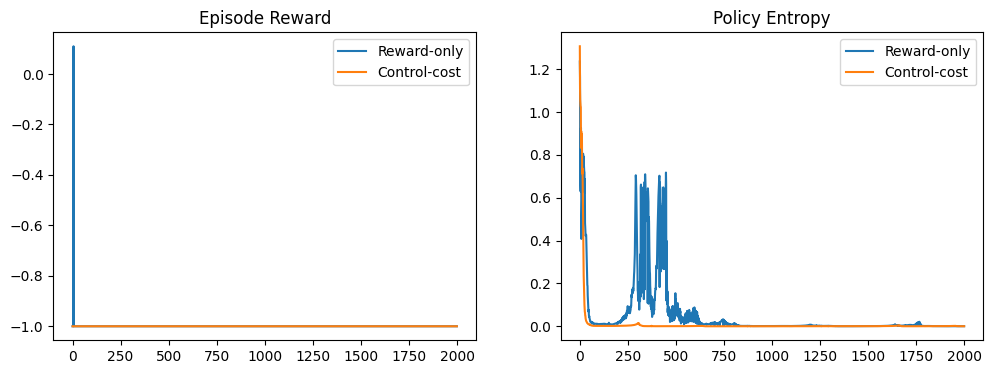

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(reward_only_rewards, label="Reward-only")
plt.plot(control_rewards, label="Control-cost")
plt.title("Episode Reward")
plt.legend()

plt.subplot(1,2,2)
plt.plot(reward_only_entropy, label="Reward-only")
plt.plot(control_entropy, label="Control-cost")
plt.title("Policy Entropy")
plt.legend()

plt.show()


In [ ]:
plt.savefig("learning_curves.png")
print("Saved plot to learning_curves.png")
